# Turunan Orde Kedua (Second Order Derivative)

## Contoh: Penurunan formula turunan kedua yang akurat orde dua

Menggunakan pendekatan deret Taylor, kita akan menurunkan formula turunan kedua yang memiliki akurasi orde dua.  
Kita akan menggunakan titik-titik yang sama dan deret Taylor yang berpusat di $x = x_n$, sehingga kita memperoleh ekspresi yang serupa seperti sebelumnya:

$$
u''(x_n) + R(x_n) = A \Bigg( 
u(x_n) + \Delta x u'(x_n) + \frac{\Delta x^2}{2!} u''(x_n) 
+ \frac{\Delta x^3}{3!} u'''(x_n) + \frac{\Delta x^4}{4!} u^{(4)}(x_n) + \mathcal{O}(\Delta x^5) 
\Bigg)
$$

$$
+ B u(x_n)
$$

$$
+ C \Bigg( 
u(x_n) - \Delta x u'(x_n) + \frac{\Delta x^2}{2!} u''(x_n) 
- \frac{\Delta x^3}{3!} u'''(x_n) + \frac{\Delta x^4}{4!} u^{(4)}(x_n) + \mathcal{O}(\Delta x^5) 
\Bigg)
$$

Kali ini kita ingin **meninggalkan $u''(x_n)$** di sisi kanan (sebagai suku yang ingin kita aproksimasi).  
Dengan melakukan langkah yang sama seperti sebelumnya, kita mendapatkan persamaan-persamaan koefisien berikut:

### Pengelompokan koefisien berdasarkan turunan:

1. Suku u(xn):  
  $$ A + B + C = 0 $$

2. Suku u'(xn):  
  $$ A Δx − C Δx = 0 $$

3. Suku u''(xn):  
  $$ A \frac{\Delta x^2}{2} + C \frac{\Delta x^2}{2} = 1$$

(Suku-suku orde lebih tinggi akan menjadi bagian dari sisa / truncation error $R(x_n)$)

### Penyelesaian sistem persamaan:

Dari persamaan kedua:  
$$A \Delta x - C \Delta x = 0 \quad \Rightarrow \quad A = C$$

Substitusi $A = C$ ke persamaan ketiga:  
$$A \frac{\Delta x^2}{2} + A \frac{\Delta x^2}{2} = 1$$
$$A \Delta x^2 = 1$$
$$A = \frac{1}{\Delta x^2}$$

Maka:  
$$C = A = \frac{1}{\Delta x^2}$$

Substitusi ke persamaan pertama:  
$$A + B + C = 0$$
$$\frac{1}{\Delta x^2} + B + \frac{1}{\Delta x^2} = 0$$
$$B + \frac{2}{\Delta x^2} = 0$$
$$B = -\frac{2}{\Delta x^2}$$

sehingga menghasilkan ekspresi akhir:

$$
u''(x_n) + R(x_n) = \frac{u(x_{n+1}) - 2u(x_n) + u(x_{n-1})}{\Delta x^2}
$$

atau secara lebih lengkap:

$$
u''(x_n) + R(x_n) = \frac{u(x_{n+1}) - 2u(x_n) + u(x_{n-1})}{\Delta x^2}
+ \frac{1}{\Delta x^2} \left( 
\frac{\Delta x^3}{3!} u'''(x_n) + \frac{\Delta x^4}{4!} u^{(4)}(x_n) 
- \frac{\Delta x^3}{3!} u'''(x_n) + \frac{\Delta x^4}{4!} u^{(4)}(x_n) 
\right) + \mathcal{O}(\Delta x^5)
$$

dengan sisa (remainder / truncation error):

$$
R(x_n) = \frac{\Delta x^2}{12} u^{(4)}(x_n) + \mathcal{O}(\Delta x^3)
$$

Ini menunjukkan bahwa formula beda hingga sentral untuk turunan kedua:

$$
u''(x_n) \approx \frac{u(x_n + \Delta x) - 2u(x_n) + u(x_n - \Delta x)}{\Delta x^2}
$$

memiliki akurasi **orde dua**, karena suku kesalahan utama berorde $\Delta x^2$ (melibatkan turunan keempat $u^{(4)}$).

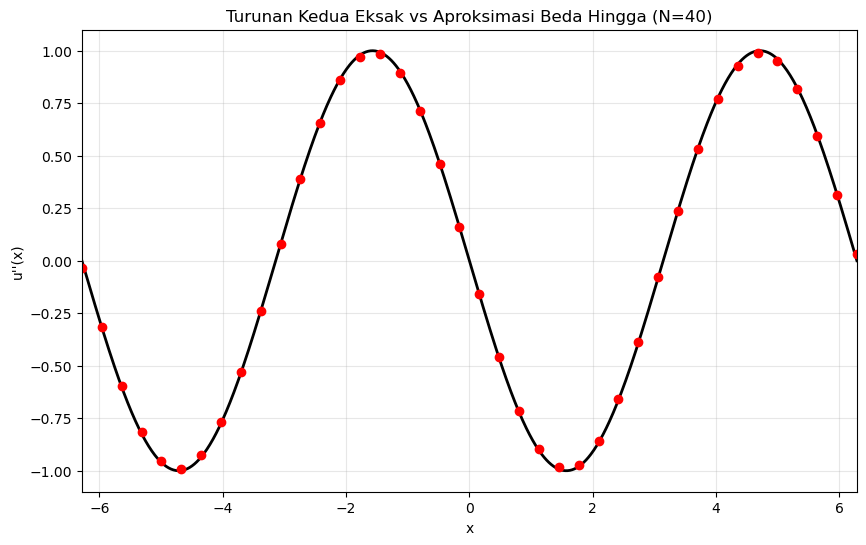

In [3]:
# Import library yang diperlukan
import numpy as np
import matplotlib.pyplot as plt

# Definisikan fungsi dan turunan keduanya secara analitik
f = lambda x: np.sin(x)                  # Fungsi u(x) = sin(x)
f_dubl_prime = lambda x: -np.sin(x)      # Turunan kedua: u''(x) = -sin(x)

# Gunakan diskritisasi seragam untuk plotting referensi
x = np.linspace(-2 * np.pi, 2 * np.pi, 1000)   # Grid halus untuk kurva eksak

# Buat grid kasar untuk aproksimasi beda hingga (N titik)
N = 40
x_hat = np.linspace(-2 * np.pi, 2 * np.pi, N)
delta_x = x_hat[1] - x_hat[0]                  # Lebar sel (step size) Δx

# Siapkan array untuk menyimpan aproksimasi turunan kedua
f_dubl_prime_hat = np.empty_like(x_hat)

# Hitung turunan kedua di titik-titik interior (central difference orde-2)
f_dubl_prime_hat[1:-1] = (
    f(x_hat[2:]) - 2.0 * f(x_hat[1:-1]) + f(x_hat[:-2])
) / (delta_x ** 2)

# Di ujung kiri (forward difference orde-2)
f_dubl_prime_hat[0] = (
    2.0 * f(x_hat[0]) - 5.0 * f(x_hat[1]) + 4.0 * f(x_hat[2]) - f(x_hat[3])
) / (delta_x ** 2)

# Di ujung kanan (backward difference orde-2)
f_dubl_prime_hat[-1] = (
    2.0 * f(x_hat[-1]) - 5.0 * f(x_hat[-2]) + 4.0 * f(x_hat[-3]) - f(x_hat[-4])
) / (delta_x ** 2)

# Buat plot tanpa legenda
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)

# Plot turunan kedua eksak (garis hitam kontinu)
ax.plot(x, f_dubl_prime(x), 'k-', linewidth=2)

# Plot aproksimasi beda hingga (titik merah)
ax.plot(x_hat, f_dubl_prime_hat, 'ro', markersize=6)

# Atur batas sumbu dan label
ax.set_xlim(x[0], x[-1])
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel('x')
ax.set_ylabel("u''(x)")
ax.set_title('Turunan Kedua Eksak vs Aproksimasi Beda Hingga (N=40)')
ax.grid(True, alpha=0.3)

# Tampilkan plot
plt.show()

# Penurunan Umum (General Derivation)

## Aproksimasi beda hingga umum untuk turunan ke-$k$ dengan stencil sewenang-wenang

Untuk aproksimasi beda hingga umum yang berpusat di $\bar{x}$ terhadap turunan ke-$k$ dengan stencil sewenang-wenang yang terdiri dari $N \geq k+1$ titik $x_1, x_2, \dots, x_N$, kita dapat menggunakan beberapa generalisasi dari metode di atas.

Perhatikan bahwa meskipun biasanya $\bar{x}$ merupakan salah satu dari titik stencil, hal ini **tidak wajib**.  
Kita juga mengasumsikan bahwa $u(x)$ cukup halus sehingga deret Taylor-nya valid.

Pada setiap titik stencil, kita memiliki ekspansi:

$$
u(x_i) = u(\bar{x}) + (x_i - \bar{x}) u'(\bar{x}) + \frac{(x_i - \bar{x})^2}{2!} u''(\bar{x}) + \cdots + \frac{(x_i - \bar{x})^k}{k!} u^{(k)}(\bar{x}) + \cdots
$$

Mengikuti metodologi sebelumnya, kita ingin mencari kombinasi linear dari ekspansi-ekspansi Taylor ini sehingga:

$$
u^{(k)}(\bar{x}) + \mathcal{O}(\Delta^p) = a_1 u(x_1) + a_2 u(x_2) + a_3 u(x_3) + \cdots + a_N u(x_N)
$$

Di sini, $\Delta$ secara umum dapat bervariasi (jarak antar titik tidak harus seragam), dan perilaku asimtotik dari metode akan ditentukan oleh semacam **rata-rata jarak** atau kadang-kadang **jarak maksimum** antar titik stencil.

### Generalisasi pendekatan dengan metode koefisien tak tentu (method of undetermined coefficients)

Kita ingin menghilangkan suku-suku dalam aproksimasi di atas yang berada di depan turunan dengan orde **kurang dari $k$**.  
Syarat untuk mencapai hal ini adalah:

Untuk $i = 1, 2, \dots, k+1$ (dan seterusnya hingga $N$ jika diperlukan), kita mempunyai:

$$
\frac{1}{(i-1)!} \sum_{j=1}^N a_j (x_j - \bar{x})^{i-1} = 
\begin{cases} 
1 & \text{jika } i-1 = k \\
0 & \text{selain itu}
\end{cases}
$$

atau secara lebih ringkas, untuk $m = 0, 1, 2, \dots, k$:

$$
\sum_{j=1}^N a_j (x_j - \bar{x})^m = 
\begin{cases} 
m! & \text{jika } m = k \\
0 & \text{jika } m = 0,1,\dots,k-1
\end{cases}
$$

(untuk $m > k$ akan menjadi bagian dari sisa / truncation error)

### Bentuk sistem persamaan

Dengan asumsi semua $x_j$ berbeda satu sama lain, sistem persamaan di atas dapat ditulis dalam bentuk **sistem Vandermonde**:

$$
\begin{bmatrix}
1 & 1 & 1 & \cdots & 1 \\
(x_1 - \bar{x}) & (x_2 - \bar{x}) & (x_3 - \bar{x}) & \cdots & (x_N - \bar{x}) \\
(x_1 - \bar{x})^2 & (x_2 - \bar{x})^2 & (x_3 - \bar{x})^2 & \cdots & (x_N - \bar{x})^2 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
(x_1 - \bar{x})^{N-1} & (x_2 - \bar{x})^{N-1} & (x_3 - \bar{x})^{N-1} & \cdots & (x_N - \bar{x})^{N-1}
\end{bmatrix}
\begin{bmatrix}
a_1 \\ a_2 \\ a_3 \\ \vdots \\ a_N
\end{bmatrix}
=
\begin{bmatrix}
0 \\ 0 \\ 0 \\ \vdots \\ k! \\ 0 \\ \vdots \\ 0
\end{bmatrix}
\qquad
\text{(suku $k!$ berada pada baris ke-$(k+1)$)}
$$

Karena matriks Vandermonde bersifat nonsingular (dengan $x_j$ saling berbeda), maka sistem ini memiliki **solusi unik** untuk koefisien $a_1, a_2, \dots, a_N$.

Solusi inilah yang memberikan bobot-bobot finite difference terbaik (dalam arti menghilangkan error orde rendah sebanyak mungkin) untuk aproksimasi turunan ke-$k$ pada titik $\bar{x}$ menggunakan stencil yang diberikan.

In [4]:
import numpy as np
import scipy.special  # Untuk menghitung faktorial secara akurat

def koefisien_beda_hingga(orde, x_pusat, titik_stencil):
    """
    Menghitung koefisien stencil beda hingga untuk aproksimasi turunan ke-orde
    pada titik x_pusat menggunakan titik-titik yang diberikan dalam array titik_stencil.
    
    Parameter:
    - orde       : orde turunan yang ingin diaproksimasi (misal: 1 untuk pertama, 2 untuk kedua)
    - x_pusat    : lokasi di mana turunan dihitung (biasanya titik pusat)
    - titik_stencil : array numpy berisi koordinat x dari titik-titik stencil
    
    Mengembalikan:
    - array koefisien c, sehingga:
      u^(orde)(x_pusat) ≈ Σ c[j] * u(titik_stencil[j])
    """
    
    N = titik_stencil.shape[0]           # Jumlah titik stencil
    A = np.ones((N, N))                  # Matriks Vandermonde (awalnya semua 1)
    x_relatif = titik_stencil - x_pusat  # Jarak relatif terhadap x_pusat
    
    # Isi baris ke-i dengan (x_j - x_pusat)^i / i!
    for i in range(1, N):
        A[i, :] = x_relatif ** i / scipy.special.factorial(i)
    
    # Vektor sisi kanan: kita ingin hanya suku orde ke-k yang bernilai 1, lainnya 0
    b = np.zeros(N)
    b[orde] = 1.0                        # Baris ke-orde harus = 1 (karena /k! sudah ada di A)
    
    # Selesaikan sistem A c = b → c adalah koefisien beda hingga
    c = np.linalg.solve(A, b)
    
    return c


# Contoh penggunaan dan hasil yang diharapkan

# 1. Turunan kedua pada stencil simetris [-1, 0, 1] (central difference klasik)
print("Turunan kedua di x=0 dengan stencil [-1, 0, 1]:")
print(koefisien_beda_hingga(2, 0.0, np.asarray([-1.0, 0.0, 1.0])))
# Hasil yang diharapkan: [1, -2, 1]  →  (f(x+1) - 2f(x) + f(x-1)) / h² dengan h=1

# 2. Turunan pertama pada stencil yang sama [-1, 0, 1]
print("\nTurunan pertama di x=0 dengan stencil [-1, 0, 1]:")
print(koefisien_beda_hingga(1, 0.0, np.asarray([-1.0, 0.0, 1.0])))
# Hasil yang diharapkan: [-0.5, 0, 0.5]  →  (f(x+1) - f(x-1)) / (2h) dengan h=1

# 3. Turunan pertama di x=-2.0 dengan stencil tidak simetris [-2,-1,0,1,2]
print("\nTurunan pertama di x=-2.0 dengan stencil [-2,-1,0,1,2]:")
print(koefisien_beda_hingga(1, -2.0, np.asarray([-2.0, -1.0, 0.0, 1.0, 2.0])))

# 4. Turunan kedua di x=0 dengan stencil satu sisi [ -1,0,1,2,3,4 ], dikalikan 12
#    (biasanya untuk melihat koefisien sebelum dibagi h², atau untuk membandingkan error)
print("\nTurunan kedua di x=0 dengan stencil satu sisi [-1,0,1,2,3,4] × 12:")
print(koefisien_beda_hingga(2, 0.0, np.asarray([-1.0, 0.0, 1.0, 2.0, 3.0, 4.0])) * 12)

Turunan kedua di x=0 dengan stencil [-1, 0, 1]:
[ 1. -2.  1.]

Turunan pertama di x=0 dengan stencil [-1, 0, 1]:
[-0.5  0.   0.5]

Turunan pertama di x=-2.0 dengan stencil [-2,-1,0,1,2]:
[-2.08333333  4.         -3.          1.33333333 -0.25      ]

Turunan kedua di x=0 dengan stencil satu sisi [-1,0,1,2,3,4] × 12:
[ 10. -15.  -4.  14.  -6.   1.]
